IMports and setup

In [ ]:
import sys
from pathlib import Path

# PROJECT_ROOT = Path.cwd().parent
# sys.path.append(str(PROJECT_ROOT))
from src.config import DATA_DIR, TARGET_COLUMN


# import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor

from src.preprocessing_utils import (
    create_sequences,
    load_feature_engineered_dataset,
    parse_datetime_index,
    scale_train_test_data,
    split_features_and_target,
)

from src.model_utils import (
    create_lstm_model,
    evaluate_regression_model,
    get_early_stopping_callback,
    plot_actual_vs_predicted,
    plot_training_history,
)

pd.set_option("display.max_columns", None)

#### Model Optimization

This notebook improves the previously developed models through hyperparameter tuning and controlled experimentation.  
The optimization focuses on Random Forest and LSTM models, followed by a comparison of performance before and after tuning.

Load datasets

In [ ]:
train_file_path = DATA_DIR / "train_feature_engineered_data.csv"
test_file_path = DATA_DIR / "test_feature_engineered_data.csv"

train_df = load_feature_engineered_dataset(train_file_path)
test_df = load_feature_engineered_dataset(test_file_path)

train_df = parse_datetime_index(train_df, datetime_column="date")
test_df = parse_datetime_index(test_df, datetime_column="date")

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

Training set shape: (15779, 41)
Testing set shape: (3945, 41)


Target and features split

In [ ]:
x_train_df, y_train_series = split_features_and_target(train_df, TARGET_COLUMN)
x_test_df, y_test_series = split_features_and_target(test_df, TARGET_COLUMN)

Scaling

In [11]:
x_train_scaled, x_test_scaled, fitted_scaler = scale_train_test_data(
    x_train=x_train_df,
    x_test=x_test_df,
    scaler_type="standard",
)

print("Scaled X_train shape:", x_train_scaled.shape)
print("Scaled X_test shape:", x_test_scaled.shape)

Scaled X_train shape: (15779, 40)
Scaled X_test shape: (3945, 40)


## Optimization
#### Optimization Strategy

Two models were selected for optimization:

- Random Forest, because it achieved the best initial performance
- LSTM, because it is the main deep learning model and may improve with better tuning

The optimization experiments focus on improving generalization and reducing prediction error.

           .................

Random Forest - Optimization

In [12]:
optimized_random_forest_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

optimized_random_forest_model.fit(
    x_train_scaled,
    y_train_series.to_numpy(),
)

optimized_random_forest_predictions = optimized_random_forest_model.predict(x_test_scaled)

optimized_random_forest_metrics = evaluate_regression_model(
    y_true=y_test_series.to_numpy(),
    y_pred=optimized_random_forest_predictions,
)

optimized_random_forest_metrics

{'MAE': 12.565313663219104, 'RMSE': 18.545138228302974}

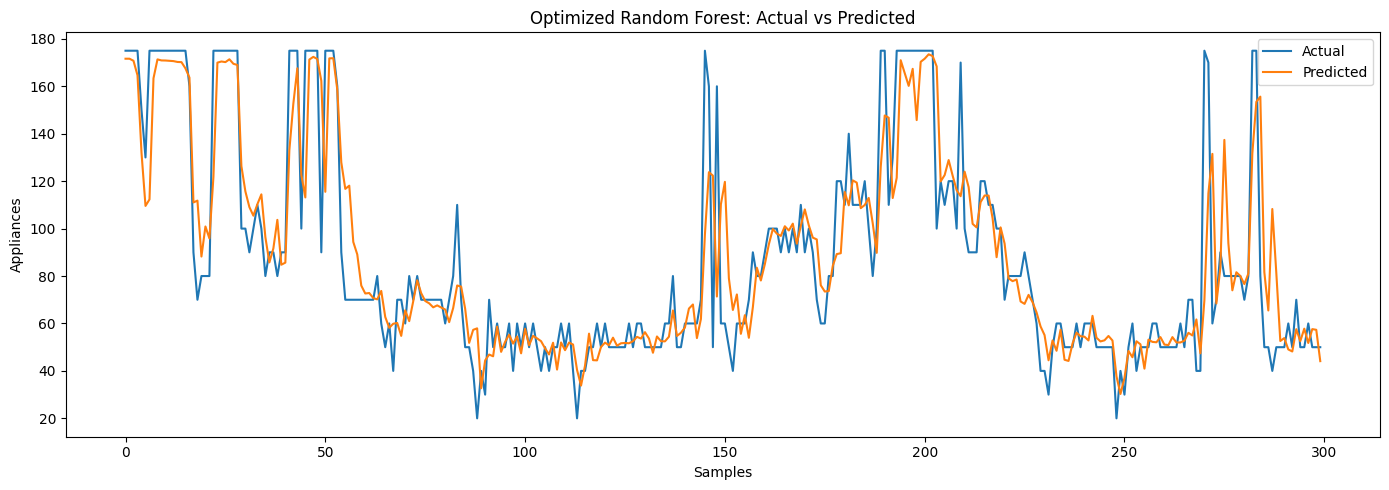

In [13]:
# plotting predictions

plot_actual_vs_predicted(
    y_true=y_test_series.to_numpy()[:300],
    y_pred=optimized_random_forest_predictions[:300],
    title="Optimized Random Forest: Actual vs Predicted",
)

- The Random Forest model was tuned by increasing the number of trees and constraining tree growth using depth and minimum sample parameters.  
- This helps reduce overfitting while preserving the model’s ability to capture non-linear relationships.

...........

LSTM

In [14]:
optimized_sequence_length = 12

x_train_seq_opt, y_train_seq_opt = create_sequences(
    x_data=x_train_scaled,
    y_data=y_train_series.to_numpy(),
    sequence_length=optimized_sequence_length,
)

x_test_seq_opt, y_test_seq_opt = create_sequences(
    x_data=x_test_scaled,
    y_data=y_test_series.to_numpy(),
    sequence_length=optimized_sequence_length,
)

print("x_train_seq_opt shape:", x_train_seq_opt.shape)
print("y_train_seq_opt shape:", y_train_seq_opt.shape)
print("x_test_seq_opt shape:", x_test_seq_opt.shape)
print("y_test_seq_opt shape:", y_test_seq_opt.shape)

x_train_seq_opt shape: (15767, 12, 40)
y_train_seq_opt shape: (15767,)
x_test_seq_opt shape: (3933, 12, 40)
y_test_seq_opt shape: (3933,)


In [15]:
# building model

optimized_lstm_model = create_lstm_model(
    input_shape=(x_train_seq_opt.shape[1], x_train_seq_opt.shape[2]),
    lstm_units=128,
    dropout_rate=0.3,
)

optimized_lstm_model.summary()

c:\Users\induw\anaconda3\envs\energy_env\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        86,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,689 (354.25 KB)

 Trainable params: 90,689 (354.25 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# training model

optimized_early_stopping = get_early_stopping_callback(patience=7)

optimized_history = optimized_lstm_model.fit(
    x_train_seq_opt,
    y_train_seq_opt,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[optimized_early_stopping],
    verbose=1,
)

Epoch 1/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 3634.5530 - mae: 45.3314 - val_loss: 777.2357 - val_mae: 18.4620
Epoch 2/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 1003.0635 - mae: 21.8347 - val_loss: 701.0398 - val_mae: 17.3100
Epoch 3/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 837.6482 - mae: 19.8089 - val_loss: 788.6454 - val_mae: 18.4760
Epoch 4/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 844.9395 - mae: 19.6375 - val_loss: 658.0198 - val_mae: 16.8873
Epoch 5/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 802.2357 - mae: 19.2126 - val_loss: 646.3329 - val_mae: 17.0889
Epoch 6/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 775.4091 - mae: 18.8796 - val_loss: 615.8935 - val_mae: 16.3186
Epoch 7/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 757.3276 - mae: 18.6809 - val_loss: 599.0532 - val_mae: 16.6033
Epoch 8/50
444/444 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 751.5428 - mae: 18.7008 - val_loss: 579.7916 - val_mae: 16.0136
Epoch 

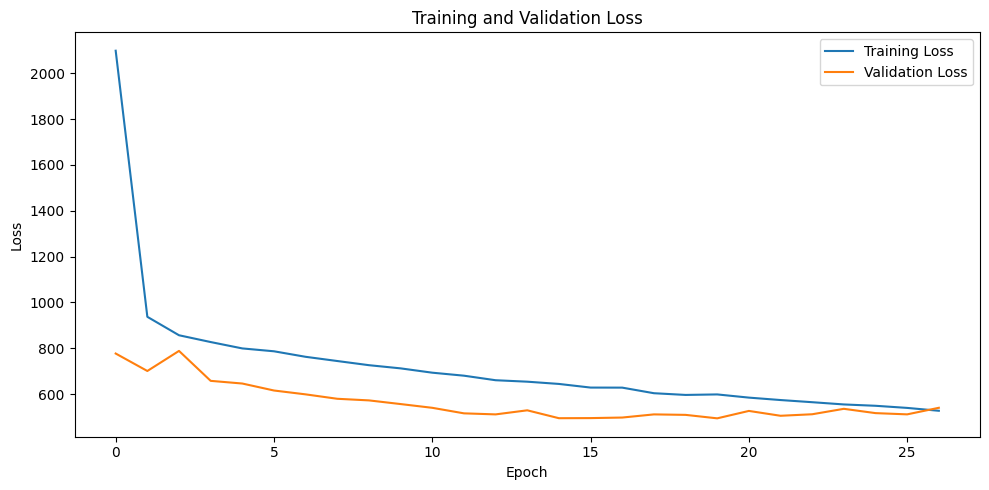

In [17]:
# plotting training

plot_training_history(optimized_history)

In [18]:
# evaluation

optimized_lstm_predictions = optimized_lstm_model.predict(x_test_seq_opt).flatten()

optimized_lstm_metrics = evaluate_regression_model(
    y_true=y_test_seq_opt,
    y_pred=optimized_lstm_predictions,
)

optimized_lstm_metrics

123/123 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


{'MAE': 16.210102081298828, 'RMSE': 24.219827344989348}

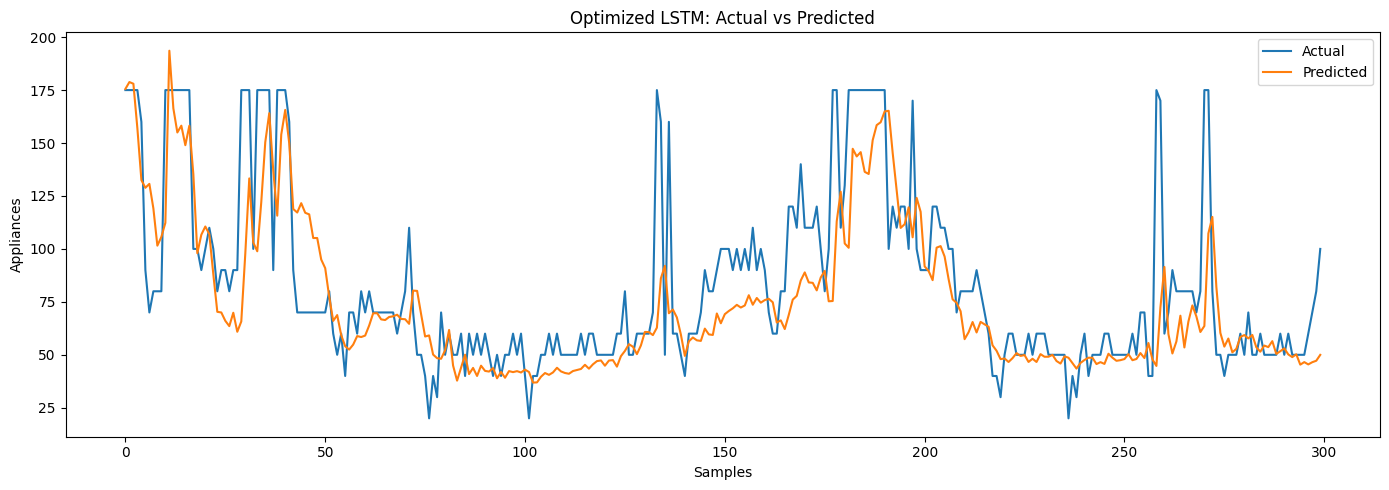

In [19]:
# plot predictions

plot_actual_vs_predicted(
    y_true=y_test_seq_opt[:300],
    y_pred=optimized_lstm_predictions[:300],
    title="Optimized LSTM: Actual vs Predicted",
)

#### Comparison

In [20]:
# results before optimization

previous_results_df = pd.DataFrame(
    [
        {"model": "Linear Regression", "MAE": 15.570595, "RMSE": 22.553753},
        {"model": "Random Forest", "MAE": 14.802757, "RMSE": 21.402411},
        {"model": "LSTM", "MAE": 16.567993, "RMSE": 25.496047},
    ]
)

previous_results_df

,model,MAE,RMSE
0,Linear Regression,15.570595,22.553753
1,Random Forest,14.802757,21.402411
2,LSTM,16.567993,25.496047


In [21]:
# results after optimization

optimized_results_df = pd.DataFrame(
    [
        {
            "model": "Optimized Random Forest",
            "MAE": optimized_random_forest_metrics["MAE"],
            "RMSE": optimized_random_forest_metrics["RMSE"],
        },
        {
            "model": "Optimized LSTM",
            "MAE": optimized_lstm_metrics["MAE"],
            "RMSE": optimized_lstm_metrics["RMSE"],
        },
    ]
)

optimized_results_df

,model,MAE,RMSE
0,Optimized Random Forest,12.565314,18.545138
1,Optimized LSTM,16.210102,24.219827


In [22]:
# results altogether

all_results_df = pd.concat(
    [previous_results_df, optimized_results_df],
    ignore_index=True,
)

all_results_df

,model,MAE,RMSE
0,Linear Regression,15.570595,22.553753
1,Random Forest,14.802757,21.402411
2,LSTM,16.567993,25.496047
3,Optimized Random Forest,12.565314,18.545138
4,Optimized LSTM,16.210102,24.219827


In [23]:
# checks

all_results_df.sort_values(by="RMSE", ascending=True)

,model,MAE,RMSE
3,Optimized Random Forest,12.565314,18.545138
1,Random Forest,14.802757,21.402411
0,Linear Regression,15.570595,22.553753
4,Optimized LSTM,16.210102,24.219827
2,LSTM,16.567993,25.496047


saving optimized model comparison

In [ ]:
optimization_results_path = DATA_DIR / "optimization_results.csv"
all_results_df.to_csv(optimization_results_path, index=False)

print(f"Saved optimization results to: {optimization_results_path}")

Saved optimization results to: e:\Vectorium Labs\energy-forecast\dataset\optimization_results.csv
